In [58]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [59]:
reliance = yf.download(
    "RELIANCE.NS",
    period="5y",
    auto_adjust=True
)

reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-06-21,1013.290527,1017.932910,996.487334,998.004605,12186448
2021-06-22,1008.082031,1024.047462,1005.183342,1020.876946,12871913
2021-06-23,998.842468,1019.336948,997.189284,1019.065241,16653951
2021-06-24,975.358826,1003.032105,969.244456,999.522015,91461975
2021-06-25,953.143005,975.358656,942.567393,975.358656,55355022


In [60]:
if isinstance(reliance.columns, pd.MultiIndex):
    reliance.columns = reliance.columns.get_level_values(0)

reliance.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-06-21,1013.290527,1017.932910,996.487334,998.004605,12186448
2021-06-22,1008.082031,1024.047462,1005.183342,1020.876946,12871913
2021-06-23,998.842468,1019.336948,997.189284,1019.065241,16653951
2021-06-24,975.358826,1003.032105,969.244456,999.522015,91461975
2021-06-25,953.143005,975.358656,942.567393,975.358656,55355022


In [61]:
reliance["Daily_Return"] = (
    reliance["Close"].pct_change()
)

In [62]:
reliance["Volatility"] = (
    reliance["Daily_Return"]
    .rolling(30)
    .std()
)

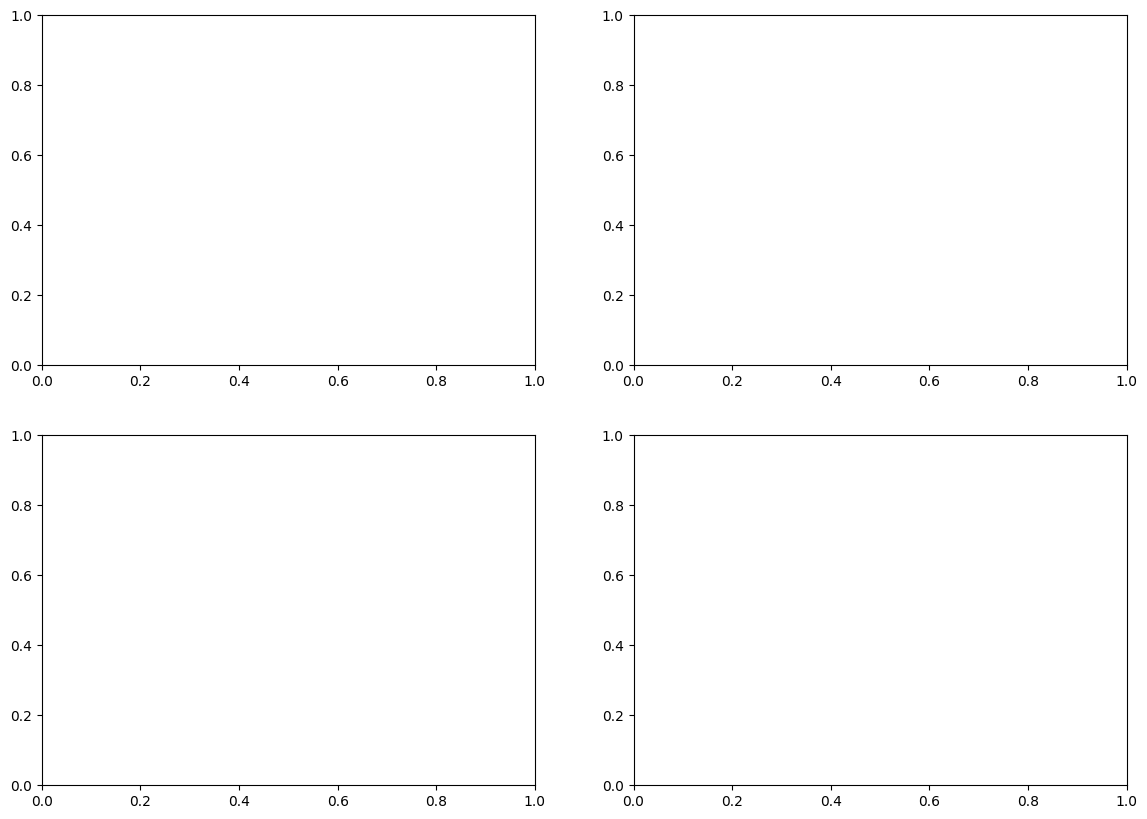

In [63]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

In [64]:
axes[0,0].plot(
    reliance.index,
    reliance["Close"],
    label="Close Price"
)

axes[0,0].set_title(
    "Reliance Closing Price"
)

axes[0,0].set_xlabel("Date")
axes[0,0].set_ylabel("Price")

axes[0,0].legend()
axes[0,0].grid(True)

In [65]:
axes[0,1].hist(
    reliance["Daily_Return"].dropna(),
    bins=40
)

axes[0,1].set_title(
    "Daily Returns Histogram"
)

axes[0,1].set_xlabel("Return")
axes[0,1].set_ylabel("Frequency")

Text(596.2626262626262, 0.5, 'Frequency')

In [66]:
axes[1,0].plot(
    reliance.index,
    reliance["Volatility"]
)

axes[1,0].set_title(
    "30-Day Rolling Volatility"
)

axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("Volatility")

axes[1,0].grid(True)

In [67]:
axes[1,1].bar(
    reliance.index,
    reliance["Volume"]
)

axes[1,1].set_title(
    "Trading Volume"
)

axes[1,1].set_xlabel("Date")
axes[1,1].set_ylabel("Volume")

Text(596.2626262626262, 0.5, 'Volume')

In [68]:
covid_date = pd.to_datetime(
    "2020-03-01"
)

for ax in axes.flat:

    ax.axvline(
        covid_date,
        color="red",
        linestyle="--"
    )

    ax.text(
        covid_date,
        ax.get_ylim()[1] * 0.9,
        "COVID Crash",
        rotation=90
    )

In [69]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [70]:
plt.savefig(
    "../images/matplotlib_chart.png",
    dpi=150
)

<Figure size 640x480 with 0 Axes>

In [71]:
plt.show()